In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
#Loading the dataset
credit_card_data = pd.read_csv('/content/creditcard.csv')

In [ ]:
credit_card_data.shape

(53571, 31)

In [ ]:
#Exploring the Dataset-First 5 columns
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
#Exploring the Dataset-Last 5 columns
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
53566,46047,-2.885416,-2.647887,1.903441,3.726885,3.800798,-1.644480,-1.924198,0.707696,-1.070468,...,0.284893,-0.268122,0.977417,0.136853,-1.144367,-0.535616,0.098494,0.305740,19.02,0.0
53567,46048,1.061410,0.045830,0.970401,1.102883,-0.490685,0.219968,-0.424285,0.235960,0.016498,...,0.033158,0.067127,0.053801,-0.010221,0.209877,-0.484136,0.057583,0.028018,28.70,0.0
53568,46048,-0.202740,0.295074,1.924698,1.009344,-0.235931,-0.272232,0.261015,-0.162146,-0.583849,...,0.321731,1.056540,0.093902,0.608566,-0.931546,0.466156,0.016695,-0.024568,54.81,0.0
53569,46048,-0.730116,0.796820,2.122484,-1.318082,0.019762,-0.857857,0.975752,-0.399896,0.359189,...,-0.149736,0.093479,-0.056586,0.650087,-0.473889,0.662115,0.060486,-0.208536,4.53,0.0
53570,46050,0.791672,-0.522991,0.036747,1.204803,-0.262390,-0.056153,0.263614,-0.130209,0.125423,...,0.013131,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Dataset Information-We can see that no null values are there
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53571 entries, 0 to 53570
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    53571 non-null  int64  
 1   V1      53571 non-null  float64
 2   V2      53571 non-null  float64
 3   V3      53571 non-null  float64
 4   V4      53571 non-null  float64
 5   V5      53571 non-null  float64
 6   V6      53571 non-null  float64
 7   V7      53571 non-null  float64
 8   V8      53571 non-null  float64
 9   V9      53571 non-null  float64
 10  V10     53571 non-null  float64
 11  V11     53571 non-null  float64
 12  V12     53571 non-null  float64
 13  V13     53571 non-null  float64
 14  V14     53571 non-null  float64
 15  V15     53571 non-null  float64
 16  V16     53571 non-null  float64
 17  V17     53571 non-null  float64
 18  V18     53571 non-null  float64
 19  V19     53571 non-null  float64
 20  V20     53571 non-null  float64
 21  V21     53571 non-null  float64
 22

In [ ]:
credit_card_data.isnull().sum()
#There are no missing values in this dataset

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#Distribution of legit and fraudulent transactions
#0->Legit transactions and 1->fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0.0,53417
1.0,153


The dataset is highly unbalanced
0-> Normal transaction
1->Fraudulent transaction

In [ ]:
#Separating the Data for Analysis
legit= credit_card_data[credit_card_data.Class==0]
fraud=credit_card_data[credit_card_data.Class==1]

In [ ]:
print(legit.shape)
print(fraud.shape)

(53417, 31)
(153, 31)


Statistical measures of the Data

In [ ]:
legit.Amount.describe()
#We can see that the mean amount of legit transactions is 88$ nearly

,Amount
count,53417.000000
mean,94.251260
std,252.353693
min,0.000000
25%,7.680000
50%,25.520000
75%,86.650000
max,12910.930000


In [ ]:
fraud.Amount.describe()
#We can see that the mean amount of fraudulent transactions is 122$, which is much higher than mean transaction amount of legit transactions

,Amount
count,153.000000
mean,97.616013
std,230.026856
min,0.000000
25%,1.000000
50%,7.610000
75%,99.990000
max,1809.680000


In [ ]:
#Comparing the values of both legit and fraud transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,30011.81811,-0.222505,-0.014659,0.722511,0.163565,-0.242775,0.109604,-0.097131,0.042665,0.104805,...,0.046251,-0.031568,-0.106396,-0.038408,0.008094,0.134794,0.019825,0.002289,0.003902,94.251260
1.0,27472.24183,-7.468948,5.326389,-10.100308,5.793812,-5.528864,-2.230554,-7.865700,3.617647,-3.492917,...,0.455720,0.891045,-0.218399,-0.277419,-0.084305,0.240593,0.136258,0.586389,0.028185,97.616013


Since the Data is quite unbalanced -90% of the data lies in legit transaction and only 10% for fraud transaction, we are using Undersampling

In [ ]:
#Building a Sample Dataset containing similar distribution of normal and fraudulent transactions
#Taking randomly 492 samples from Legit transaction to create a balanced dataset

legit_sample = legit.sample(n=492)

Concatening both Legit and Fraud dataframes row wise

In [ ]:
New_dataset = pd.concat([legit_sample,fraud],axis=0)

In [ ]:
New_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
8563,11541,-0.571566,0.745703,3.589548,3.469756,-0.375417,1.085845,-0.172229,0.050395,1.045838,...,-0.245180,0.067412,-0.223953,0.384286,0.098654,0.248379,-0.044099,-0.123243,28.51,0.0
30199,35818,-2.780981,0.867944,1.662327,-0.988152,-1.316793,1.123245,-1.523188,-5.370199,0.065874,...,-2.660722,0.959150,0.201617,0.364308,-0.144592,0.766479,-0.962991,-0.677419,113.92,0.0
28448,35016,-0.693292,0.424121,0.998210,0.194692,-1.106451,-0.290015,0.479518,0.451500,-0.322999,...,0.290006,0.446080,0.493760,0.396883,-0.519735,0.351783,-0.137522,-0.011321,170.80,0.0
37430,38952,1.046979,-1.249340,-1.718460,-1.602458,1.483850,3.067420,-0.388136,0.610922,-1.277089,...,-0.727615,-2.326080,0.063822,0.978939,0.069346,0.616174,-0.113801,0.039548,225.00,0.0
36189,38428,-1.726718,-0.491016,2.336328,1.329864,0.326453,0.726576,-0.303816,0.310200,0.800764,...,-0.007433,0.663823,0.075483,-0.526360,0.923045,0.081859,0.325493,0.164132,69.34,0.0


In [ ]:
New_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
50211,44393,-4.617461,3.663395,-5.297446,3.880960,-3.263551,-0.918547,-5.715262,0.831040,-2.457034,...,2.698175,-0.027081,0.366775,-0.123011,-0.300457,-0.239996,-0.183463,-0.073360,1.00,1.0
50537,44532,-0.234922,0.355413,1.972183,-1.255593,-0.681387,-0.665732,0.059110,-0.003153,1.122451,...,0.220670,0.912107,-0.286338,0.451208,0.188315,-0.531846,0.123185,0.039581,1.00,1.0
52466,45463,-1.476893,2.122314,-1.229470,1.201849,-0.343264,-1.317704,-1.528142,-0.620953,-1.213040,...,1.186036,-0.040215,-0.238930,0.110144,0.045418,-0.569232,0.481019,-0.047555,1.00,1.0
52521,45501,1.001992,0.047938,-0.349002,1.493958,0.186939,0.190966,-0.001112,0.147140,0.580415,...,-0.334417,-1.014315,-0.128427,-0.946242,0.456090,-0.453206,0.046627,0.064698,105.99,1.0
52584,45541,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,...,1.307871,0.102826,-0.017746,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,1.00,1.0


In [ ]:
New_dataset['Class'].value_counts()
#Verifying the size of our New dataset- its evenly balanced now

,count
Class,
0.0,492
1.0,153


In [ ]:
New_dataset.groupby('Class').mean()
# Mean remains similar even now for fraud transactions after undersampling as well.

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,29825.514228,-0.173934,0.046270,0.749372,0.083668,-0.266823,0.160279,-0.120108,0.135503,0.033882,...,0.05520,-0.053694,-0.050168,-0.067927,0.023570,0.108595,0.016430,-0.011411,0.011397,86.301768
1.0,27472.241830,-7.468948,5.326389,-10.100308,5.793812,-5.528864,-2.230554,-7.865700,3.617647,-3.492917,...,0.45572,0.891045,-0.218399,-0.277419,-0.084305,0.240593,0.136258,0.586389,0.028185,97.616013


Splitting the Data into features and targets

In [ ]:
X= New_dataset.drop(columns = 'Class',axis =1)
Y= New_dataset['Class']

In [ ]:
X.head()
#Column Class is dropped from X now

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
8563,11541,-0.571566,0.745703,3.589548,3.469756,-0.375417,1.085845,-0.172229,0.050395,1.045838,...,0.314209,-0.245180,0.067412,-0.223953,0.384286,0.098654,0.248379,-0.044099,-0.123243,28.51
30199,35818,-2.780981,0.867944,1.662327,-0.988152,-1.316793,1.123245,-1.523188,-5.370199,0.065874,...,0.971464,-2.660722,0.959150,0.201617,0.364308,-0.144592,0.766479,-0.962991,-0.677419,113.92
28448,35016,-0.693292,0.424121,0.998210,0.194692,-1.106451,-0.290015,0.479518,0.451500,-0.322999,...,0.118817,0.290006,0.446080,0.493760,0.396883,-0.519735,0.351783,-0.137522,-0.011321,170.80
37430,38952,1.046979,-1.249340,-1.718460,-1.602458,1.483850,3.067420,-0.388136,0.610922,-1.277089,...,0.086095,-0.727615,-2.326080,0.063822,0.978939,0.069346,0.616174,-0.113801,0.039548,225.00
36189,38428,-1.726718,-0.491016,2.336328,1.329864,0.326453,0.726576,-0.303816,0.310200,0.800764,...,0.251310,-0.007433,0.663823,0.075483,-0.526360,0.923045,0.081859,0.325493,0.164132,69.34


In [ ]:
print(Y)
#Y has Class with both legit and fraud values

8563     0.0
30199    0.0
28448    0.0
37430    0.0
36189    0.0
        ... 
50211    1.0
50537    1.0
52466    1.0
52521    1.0
52584    1.0
Name: Class, Length: 645, dtype: float64


Splitting the data into Training and Testing data

In [ ]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size = 0.2,stratify=Y,random_state=2)

In [ ]:
#Checking the shape and distribution of X training and testing data
print(X.shape,X_train.shape,X_test.shape)

(645, 30) (516, 30) (129, 30)


In [ ]:
#Checking the shape and distribution of Y training and testing data
print(Y.shape,Y_train.shape,Y_test.shape)

(645,) (516,) (129,)


Model Training for Logistic Regression

To tackle the convergence issue , we are scaling the dataset

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#Training on scaled Data

model=LogisticRegression(max_iter=1000,solver='liblinear',class_weight='balanced')
model.fit(X_train_scaled,Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

Model Evaluation

In [ ]:
#Accuracy on training data
X_train_prediction= model.predict(X_train_scaled)
training_data_accuracy= accuracy_score(X_train_prediction,Y_train)

In [ ]:
print('Accuracy on training data:', training_data_accuracy)

Accuracy on training data: 0.9864341085271318


In [ ]:
#Checking Accuracy on test data
X_test_prediction = model.predict(X_test_scaled)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)

In [ ]:
print('Accuracy on test data:', test_data_accuracy)

Accuracy on test data: 0.9612403100775194


Predicting Values for Test set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Y_pred=model.predict(X_test_scaled)

In [ ]:
print(confusion_matrix(Y_test,Y_pred)) #Prediction vs Reality

[[96  2]
 [ 3 28]]


In [ ]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97        98
         1.0       0.93      0.90      0.92        31

    accuracy                           0.96       129
   macro avg       0.95      0.94      0.95       129
weighted avg       0.96      0.96      0.96       129



Visualization

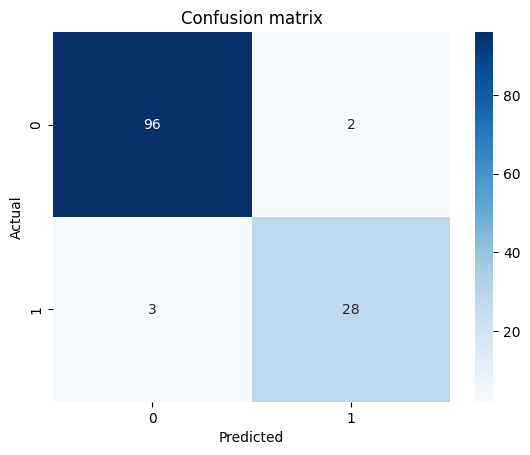

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(Y_test,Y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

Model Training for Decision Tree Classifier

In [ ]:
# Importing Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#Training decision tree
dt_model= DecisionTreeClassifier(class_weight='balanced',random_state=42)
dt_model.fit(X_train_scaled,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
#Predictions
Y_pred_dt=dt_model.predict(X_test_scaled)

In [ ]:
#Evaluation
print("Decision Tree Classification Report:\n")
print(classification_report(Y_test, Y_pred_dt))

#wherein Precision shows how correct frauds are, recall shows how many frauds were caught,f1-score shows balance between precision and recall
#support shows number of actual samples

#For Fraud-Precision = 0.88 which shows more false alarms and Recall = 0.94 signifying that it Catches more fraud

Decision Tree Classification Report:

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        98
         1.0       0.88      0.94      0.91        31

    accuracy                           0.95       129
   macro avg       0.93      0.95      0.94       129
weighted avg       0.96      0.95      0.95       129



In [ ]:
#Accuracy
dt_accuracy = accuracy_score(Y_test, Y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9534883720930233


In [ ]:
#Logistic Regression classification report comparision
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97        98
         1.0       0.93      0.90      0.92        31

    accuracy                           0.96       129
   macro avg       0.95      0.94      0.95       129
weighted avg       0.96      0.96      0.96       129



Model Comparison:-

- Decision Tree achieved higher recall (0.94), meaning it detected more fraud cases, but had lower precision (0.88), leading to more false positives.
- Logistic Regression provided better precision (0.93) with slightly lower recall (0.90), resulting in more balanced and reliable predictions.

Conclusion:

Logistic Regression is preferred as it maintains a better balance between precision and recall, reducing false alarms while still effectively detecting fraud.